# Pre-series04-Python

## Import libraries

In [13]:
import numpy as np 
import matplotlib.pyplot as plt

# 1. Generate a known signal 

Equation of a sinusoid at 1Hz, with amplitude 1 and phase 0 :
$$s(t) = A\sin(2\pi f t + \varphi),\quad A=1,\ f=1\,\text{Hz},\ \varphi=0 \;\Rightarrow\; s(t)=\sin(2\pi t)$$

We build a 3D signal $(x, y, z)$ from the same 1 Hz sinusoid, with a constant phase shift $\Delta\varphi = \pi/4$ applied successively from one axis to the next: $y$ is shifted by $\Delta\varphi$ relative to $x$, and $z$ is shifted by $\Delta\varphi$ relative to $y$. Therefore, $z$ is shifted by $2\Delta\varphi = \pi/2$ relative to $x$:

$$x(t)=\sin(2\pi t),\quad y(t)=\sin\!\left(2\pi t+\tfrac{\pi}{4}\right),\quad z(t)=\sin\!\left(2\pi t+\tfrac{\pi}{2}\right)$$

In general, for axis $k \in \{0, 1, 2\}$ (x, y, z): $s_k(t) = \sin(2\pi t + k\,\Delta\varphi)$. This is implemented with `phases = phi0 + phase_shift * np.arange(3)`, and NumPy broadcasting applies one phase per column of `time` (shape `(n, 1)`).

In [14]:
# Parameters 

f = 1.0                 # frequency (Hz)
A = 1.0                 # amplitude
phi0 = 0.0              # initial phase (rad)
n_samples = 100       # number of samples
duration = 3.0          # duration (s)
phase_shift = np.pi / 4 # phase shift between x->y and y->z (rad)

# Time vector

time = np.linspace(0, duration, n_samples).reshape(-1, 1)   # shape (n, 1)

# Signal (x, y, z) in columns

phases = phi0 + phase_shift * np.arange(3)           # [0, pi/4, pi/2]
signal = A * np.sin(2 * np.pi * f * time + phases)   # broadcasting -> (n, 3)

# Check 

print(f"t.shape = {time.shape}")
print(f"s.shape = {signal.shape}")
print(f"phase_shift = {phase_shift/np.pi:g} pi")



t.shape = (100, 1)
s.shape = (100, 3)
phase_shift = 0.25 pi


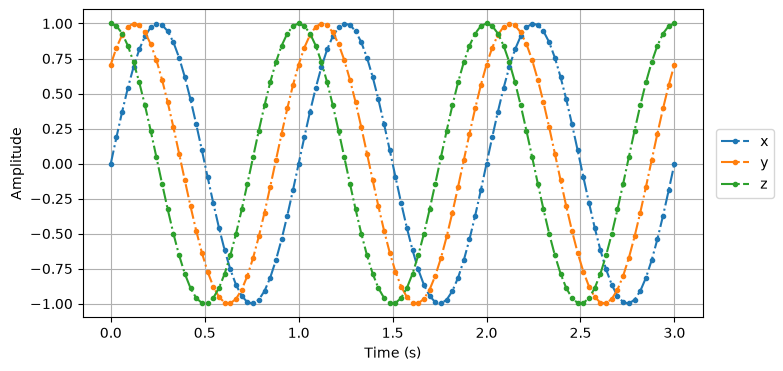

In [15]:
# Plot 2D figure 

fig2d, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate("xyz"):
    ax.plot(time, signal[:, i], ".-.", label=name)   # points reliés en pointillés
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

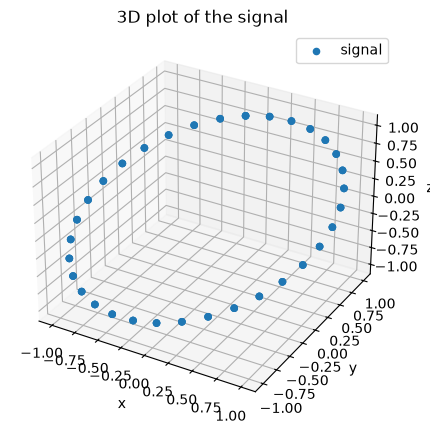

In [16]:
# Plot 3D figure

fig3d = plt.figure(figsize=(6, 5))
ax3 = fig3d.add_subplot(projection="3d")
ax3.scatter(signal[:, 0], signal[:, 1], signal[:, 2], label="signal")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.set_title("3D plot of the signal")
ax3.legend()
plt.show()

# 2. Estimate the time derivative of the signal 

## 2.1 Derivative of a sine wave 

Let $s(t)=A\sin(\theta(t))$ with $\theta(t)=2\pi f t+\varphi$, so that $\theta'(t)=2\pi f$.
We use Euler's formulas from the mathematical analysis course (eq. 1.40 and 1.41, §1.5.2 of reference 1):

$$\sin\theta=\frac{e^{i\theta}-e^{-i\theta}}{2i},\qquad \cos\theta=\frac{e^{i\theta}+e^{-i\theta}}{2}$$

and the derivative of a complex exponential, $\dfrac{d}{dt}e^{\pm i\theta(t)}=\pm i\,\theta'(t)\,e^{\pm i\theta(t)}$. Then

$$\frac{ds}{dt}=A\,\frac{i\theta'e^{i\theta}+i\theta'e^{-i\theta}}{2i}
=A\,\theta'\,\frac{e^{i\theta}+e^{-i\theta}}{2}
=2\pi f\,A\cos(2\pi f t+\varphi)$$

Applied to each axis of our signal ($A=1$, $f=1$ Hz, phases $0,\ \pi/4,\ \pi/2$):

$$\frac{dx}{dt}=2\pi\cos(2\pi t),\quad
\frac{dy}{dt}=2\pi\cos\!\left(2\pi t+\tfrac{\pi}{4}\right),\quad
\frac{dz}{dt}=2\pi\cos\!\left(2\pi t+\tfrac{\pi}{2}\right)$$

The derivative of a sine is a cosine, i.e. a sine **advanced by $\pi/2$**, with an amplitude multiplied by $2\pi f$.


## 2.2 Forward vs. central difference

In practice we only have samples $s_i = s(t_i)$, so the derivative is approximated by a finite difference
(reference 2).

**Forward difference** uses the current sample and the next one:

$$\dot s_i \approx \frac{s_{i+1}-s_i}{t_{i+1}-t_i}$$

**Central difference** uses the samples before and after the current one:

$$\dot s_i \approx \frac{s_{i+1}-s_{i-1}}{t_{i+1}-t_{i-1}}$$

Differences between the two methods (with a step $h = t_{i+1}-t_i$), from the Taylor expansion $s(t+h)=s(t)+h\,s'(t)+\tfrac{h^2}{2}s''(t)+\tfrac{h^3}{6}s'''(t)+\dots$:

- **Accuracy:** the forward difference has an error of order $O(h)$ (the $s''$ term remains). In the central difference, the $s''$ terms cancel, so the error is of order $O(h^2)$.
- **Time localisation:** the forward estimate is really the slope between $t_i$ and $t_{i+1}$ (it is centred at $t_i+h/2$, hence a small time lag). The central estimate is centred exactly at $t_i$.
- **Edges:** the forward difference needs the *next* sample, so it is undefined for the last sample. The central difference needs both neighbours, so it is undefined for the first and the last samples. To keep the output the same shape as the input, we use one-sided differences at the borders (see 3.3).
- **Noise:** both amplify noise, the central difference slightly less since it averages over a wider window.

## 2.3 Function design

- **Input order: `(signal, time)`.** The signal is the main object we operate on, and the time vector is the coordinate along which we differentiate. This is the same convention as `np.gradient(f, x)` or `np.trapz(y, x)`. Both arrays have the samples over rows (axis 0), so `signal` is `(n, d)` and `time` is `(n, 1)` and they broadcast together.
- **Output shape: `(n, d)`**, the same as `signal`: one derivative value per sample and one column per dimension, so that the derivative can be plotted or combined with the signal directly. The two methods give $n-1$ and $n-2$ estimates by definition, so the borders are completed with one-sided differences:
  - forward difference: the last sample reuses the last interval (backward difference);
  - central difference: the first sample uses a forward difference and the last sample a backward difference (same behaviour as `np.gradient`).

In [20]:
# See reference 2 for the finite-difference formulas (forward, backward, central):

def forward_difference(signal, time):
    """Time derivative with the forward difference.

    signal : (n, d) array, samples over rows, dimensions over columns
    time   : (n, 1) array (or (n,)), measurement dates over rows
    returns: (n, d) array. Row i uses samples i and i+1.
             The last row has no "next" sample: it reuses the last interval
             (i.e. a backward difference), so the output keeps the shape of `signal`.
    """
    signal = np.asarray(signal, dtype=float)
    time = np.asarray(time, dtype=float).reshape(-1, 1)
    assert signal.shape[0] == time.shape[0], "signal and time must have the same number of samples"
    d = np.diff(signal, axis=0) / np.diff(time, axis=0)    # (n-1, d)
    return np.vstack([d, d[-1:]])                          # (n, d)

def central_difference(signal, time):
    """Time derivative with the central difference.

    signal : (n, d) array, samples over rows, dimensions over columns
    time   : (n, 1) array (or (n,)), measurement dates over rows
    returns: (n, d) array. Interior rows use samples i-1 and i+1.
             The first row uses a forward difference and the last row a
             backward difference (no neighbour on one side), so the output
             keeps the shape of `signal`.
    """
    signal = np.asarray(signal, dtype=float)
    time = np.asarray(time, dtype=float).reshape(-1, 1)
    assert signal.shape[0] == time.shape[0], "signal and time must have the same number of samples"
    d = np.empty_like(signal)
    d[1:-1] = (signal[2:] - signal[:-2]) / (time[2:] - time[:-2])
    d[0] = (signal[1] - signal[0]) / (time[1] - time[0])
    d[-1] = (signal[-1] - signal[-2]) / (time[-1] - time[-2])
    return d

# Apply the finite-difference formulas to the signal

d_fwd = forward_difference(signal, time)
d_cen = central_difference(signal, time)
print(f"signal : {signal.shape}   forward : {d_fwd.shape}   central : {d_cen.shape}")

# Sanity check against the analytical derivative:
d_true = 2 * np.pi * f * A * np.cos(2 * np.pi * f * time + phases)
print("max abs error, forward :", np.abs(d_fwd - d_true).max().round(3))
print("max abs error, central :", np.abs(d_cen - d_true).max().round(3))

signal : (100, 3)   forward : (100, 3)   central : (100, 3)
max abs error, forward : 0.597
max abs error, central : 0.596


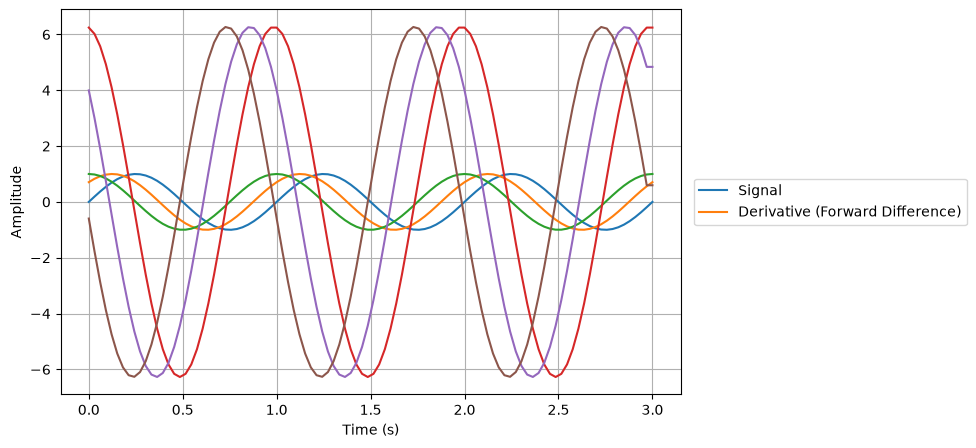

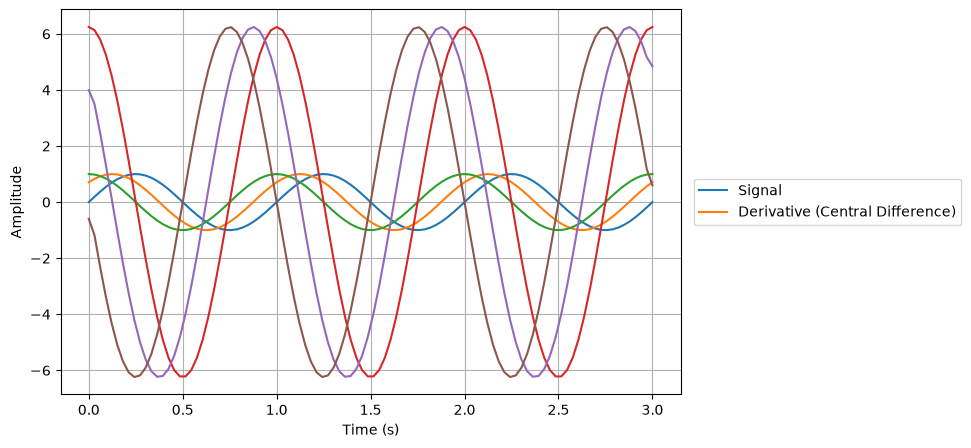

In [26]:
# Plots : signal and derivative on the same axes

def plot_signal_and_derivative(signal, deriv, time, method):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i in range(3):
        ax.plot(time, signal[:, i], color=f"C{i}")        # signal: C0, C1, C2
    for i in range(3):
        ax.plot(time, deriv[:, i], color=f"C{i + 3}")     # derivative: C3, C4, C5
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True)
    handles = [Line2D([], [], color="C0", label="Signal"),
               Line2D([], [], color="C1", label=f"Derivative ({method})")]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5))
    plt.show()

plot_signal_and_derivative(signal, d_fwd, time, "Forward Difference")
plot_signal_and_derivative(signal, d_cen, time, "Central Difference")

# 3 Estimate the tangential speed of the signal 

## 4.1 Tangential velocity vs. tangential speed

- The **velocity** is a **vector**: the time derivative of the position, $\vec v(t)=\dfrac{d\vec r}{dt}$. It tells *how fast* and *in which direction* the object moves, and it is always tangent to the trajectory (for a circular motion, tangent to the circle: this is the "tangential velocity") [3].
- The **tangential speed** is a **scalar**: the *magnitude* (norm) of that vector, $v(t)=\lVert\vec v(t)\rVert=\dfrac{ds}{dt}$, where $s$ is the distance travelled along the path. It is always $\geq 0$ and has no direction [3, 4]. For a circular motion of radius $r$ and angular speed $\omega$: $v=\omega r$.

Example: moving at $-2$ m/s along an axis has a velocity of $-2$ m/s (it goes backwards) but a speed of $2$ m/s.


## 4.2 Tangential speed of a 3D movement

For a small displacement $(dx, dy, dz)$, Pythagoras gives the travelled distance $ds^2=dx^2+dy^2+dz^2$. Dividing by $dt^2$ and taking the square root:

$$v(t)=\frac{ds}{dt}=\sqrt{\left(\frac{dx}{dt}\right)^2+\left(\frac{dy}{dt}\right)^2+\left(\frac{dz}{dt}\right)^2}=\sqrt{\dot x^2+\dot y^2+\dot z^2}$$